# Temporal Pattern Analysis — TD4C → RTP KarmaLego → KLS → LogReg / XGBoost

**Input:** `dataset_clean.csv` — 8,437 Monday rows, 25 tickers, April 2016 – December 2024. Primary set (`is_extreme_event == 0`) used for all training and evaluation.

**Goal:** Engineer a set of *multi-week temporal pattern* features from the heterogeneous feature set, then evaluate whether those features alone give LogReg and XGBoost a signal for `GapUp`. No LSTM.

### Methodology

Four stages:

| Stage | What | Motivation |
|-------|------|-----------|
| 1. **TD4C** (Temporal Discretization for Classification) | For each continuous weekly feature, find `k-1` cutpoints that maximise information gain w.r.t. `GapUp` — the cutpoints are *supervised*, so each resulting symbol (e.g. `ATR=high`) is one that actually separates the two classes in the training data. | Avoids throwing class signal away at the abstraction step; a naive tertile split would discretise without regard to the target. |
| 2. **Weekly symbolic intervals** | Apply the TD4C cutpoints to each weekly aggregated value → one symbol per ticker-week. Consecutive same-symbol weeks are merged into a single interval `[start_week, end_week]`. | One week is the base time unit (data is already weekly-aggregated). Intervals are therefore *multi-week regimes*. |
| 3. **RTP-anchored KarmaLego** | Mine frequent TIRPs per-ticker with multi-entity vertical support (a TIRP is frequent if it appears in ≥ `min_ticker_support` of the 25 tickers). Allen relations are the standard 7: `before`, `meets`, `overlaps`, `finished-by`, `contains`, `starts`, `equal`. **RTP semantics** are applied at feature-time: a TIRP is *recent* to a prediction anchor (ticker-week) only if its last interval ends within `max_lag` weeks before that week — this is the Recent-Temporal-Patterns framework of Moskovitch-Shahar-Pontil. | Mining once globally + anchoring at feature-time gives the same result as recomputing RTP support per anchor but is far cheaper. |
| 4. **KLS features → LogReg + XGBoost** | For each frequent TIRP `T` and each (ticker, week) prediction anchor, a binary feature `x_T = 1` iff some instance of `T` in that ticker's history ends within `max_lag` weeks before the anchor. These binary columns form the entire feature matrix. Walk-forward expanding-window evaluation identical to the other model notebooks in the project. | KarmaLegoSification (Moskovitch & Shahar, 2015) — pattern-indicator features are scale-free, handle heterogeneous variables uniformly, and are directly consumable by any classifier. |

### Leakage-avoidance discipline

- COVID rows (`is_extreme_event == 1`, Feb–May 2020) are excluded from all training, mining, and evaluation — matches the other model notebooks.
- The leaky weekly price aggregates (`WeeklyReturn`, `IntraWeekVolatility`, `FridayPosition`, `OpenCloseSpread`) are never referenced.
- **Earliest-fold training window (2016 – 2018) is used to fit TD4C cutpoints and to mine the frequent TIRPs.** The resulting discretisation and pattern set are then reused across all walk-forward folds. This means the test year of every fold is held out from the TIRP-discovery step — no peeking into test data for either discretisation thresholds or pattern structure. The classifier itself is re-fit per fold on expanding train windows.

### Compute budget

Parameter defaults chosen so the notebook runs in under a minute on a laptop:
- `n_states = 3` per variable (low / mid / high TD4C bins)
- `min_ticker_support = 8` tickers (~1/3 of 25)
- `max_gap = 8` weeks for the `before` relation
- `max_lag = 4` weeks for RTP anchor realisation
- `max_k = 3` — mine TIRPs of size 2 and 3.

In [1]:
from __future__ import annotations

import warnings
from collections import defaultdict, Counter
from dataclasses import dataclass, field
from enum import IntEnum
from bisect import bisect_left, bisect_right

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve

try:
    from xgboost import XGBClassifier
    _HAS_XGB = True
except ImportError:
    _HAS_XGB = False
    warnings.warn('xgboost not installed — XGBoost evaluation cell will be skipped.')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
pd.options.display.float_format = '{:.4f}'.format
np.random.seed(42)
%matplotlib inline

## Stage 1 — Load data, define feature set, exclude COVID and leaky columns

The continuous features we will discretise with TD4C are the 15 model features used by the project's LogReg / XGBoost pipelines (momentum, trend, volatility, volume, fundamental — see `Notes.txt` §9 Feature Set Summary):

In [2]:
DATASET_PATH = '../structured_csv_data_files/fetched_data/dataset_clean.csv'

# 15 continuous features used across LogReg/XGBoost (post-VIF pruning of RSI/GrossMargin/WeeklyRange)
CONTINUOUS_FEATURES = [
    # Momentum
    'MACD', 'ROC', 'StochPercK',
    # Trend
    'CloseVEma50', 'CloseVSma20', 'ADX',
    # Volatility
    'BollingerBandWidth', 'ATR', 'FiveDStdDev',
    # Volume
    'OBV', 'MFI', 'VolumeRatio',
    # Fundamental
    'NetMargin', 'RoA', 'RevGrowthQoQ',
]
TARGET = 'GapUp'

df_all = pd.read_csv(DATASET_PATH)
df_all['Date'] = pd.to_datetime(df_all['Date'], utc=True).dt.tz_convert(None)

# Primary set only — exactly matches LogReg / XGBoost / LSTM notebook convention
primary = df_all[df_all['is_extreme_event'] == 0].copy()
primary = primary.sort_values(['Ticker', 'Date']).reset_index(drop=True)
# Per-ticker week index (0, 1, 2, ... within each ticker's history)
primary['WeekIdx'] = primary.groupby('Ticker').cumcount()

assert primary[CONTINUOUS_FEATURES].isna().sum().sum() == 0, 'NaN in continuous features — should not happen after eda.ipynb cleaning'

print(f'Primary rows: {len(primary):,}')
print(f'Tickers:       {primary["Ticker"].nunique()}')
print(f'Date range:    {primary["Date"].min().date()}  →  {primary["Date"].max().date()}')
print(f'GapUp rate:    {primary[TARGET].mean():.3f}')
print(f'Continuous features ({len(CONTINUOUS_FEATURES)}): {CONTINUOUS_FEATURES}')

Primary rows: 8,146
Tickers:       25
Date range:    2016-04-18  →  2024-12-23
GapUp rate:    0.516
Continuous features (15): ['MACD', 'ROC', 'StochPercK', 'CloseVEma50', 'CloseVSma20', 'ADX', 'BollingerBandWidth', 'ATR', 'FiveDStdDev', 'OBV', 'MFI', 'VolumeRatio', 'NetMargin', 'RoA', 'RevGrowthQoQ']


## Stage 2 — TD4C supervised discretisation

For each continuous feature we search for the `n_states - 1` cutpoints that maximise **information gain** between the resulting bins and the `GapUp` target:

$$
\mathrm{IG} \;=\; H(Y) - \sum_{b} \frac{|b|}{N}\,H(Y\mid X \in b)
$$

- `H(Y)` is the entropy of the binary target in the training data.
- `H(Y | X ∈ b)` is the entropy of the target conditional on `X` falling in bin `b`.
- A bin with a strongly class-imbalanced distribution contributes low conditional entropy → high `IG`.

We use `n_states = 3` (labels `low` / `mid` / `high`) and exhaustively search all pairs of percentile-based candidate cutpoints (every 5th percentile between the 5th and the 95th → 19 candidates per variable, ~170 pairs per variable).

**Important — leakage discipline:** cutpoints are fit on the earliest walk-forward training window only (2016 – 2018 of `primary`). Every subsequent fold's test year is therefore absent from the discretisation data.

In [3]:
def _binary_entropy(p: float) -> float:
    """Shannon entropy of a Bernoulli(p), in bits. H(0)=H(1)=0 by convention."""
    if p <= 0 or p >= 1:
        return 0.0
    return -p * np.log2(p) - (1.0 - p) * np.log2(1.0 - p)


def td4c_cutpoints(
    values:  np.ndarray,
    labels:  np.ndarray,
    n_states: int = 3,
    n_candidates: int = 19,
) -> list[float]:
    """Find `n_states - 1` cutpoints for `values` maximising information gain w.r.t. `labels`.

    Parameters
    ----------
    values       : 1D float array (feature values on the TRAINING set only).
    labels       : 1D 0/1 int array, same length as values.
    n_states     : number of desired bins. Currently supports 2 or 3.
    n_candidates : number of percentile-based candidate cutpoints to consider.
                   They are spaced uniformly from 5% to 95%.

    Returns
    -------
    cuts : sorted list of length n_states - 1 giving the bin boundaries.
           Bin 0 is (-inf, cuts[0]); bin i is [cuts[i-1], cuts[i]); last bin is [cuts[-1], +inf).
    """
    assert n_states in (2, 3), 'n_states must be 2 or 3 (extendable trivially)'
    assert len(values) == len(labels)
    assert values.ndim == 1

    pcts = np.linspace(5, 95, n_candidates)
    candidates = np.unique(np.percentile(values, pcts))
    if len(candidates) < n_states - 1:
        # degenerate variable (constant / near-constant) — fall back to median
        return [float(np.median(values))] * (n_states - 1)

    N = len(labels)
    p_full = labels.mean()
    H_Y = _binary_entropy(p_full)

    best_ig = -np.inf
    best_cuts: list[float] = []

    if n_states == 2:
        for c in candidates:
            low = values < c
            n_l = int(low.sum()); n_h = N - n_l
            if n_l == 0 or n_h == 0: continue
            p_l = labels[low].mean()
            p_h = labels[~low].mean()
            H_c = (n_l / N) * _binary_entropy(p_l) + (n_h / N) * _binary_entropy(p_h)
            ig = H_Y - H_c
            if ig > best_ig:
                best_ig = ig; best_cuts = [float(c)]
    else:
        # n_states == 3
        for i, c1 in enumerate(candidates):
            for c2 in candidates[i+1:]:
                m_lo = values < c1
                m_md = (values >= c1) & (values < c2)
                m_hi = values >= c2
                n_lo = int(m_lo.sum()); n_md = int(m_md.sum()); n_hi = int(m_hi.sum())
                if n_lo == 0 or n_md == 0 or n_hi == 0:
                    continue
                H_c = (
                    (n_lo / N) * _binary_entropy(labels[m_lo].mean()) +
                    (n_md / N) * _binary_entropy(labels[m_md].mean()) +
                    (n_hi / N) * _binary_entropy(labels[m_hi].mean())
                )
                ig = H_Y - H_c
                if ig > best_ig:
                    best_ig = ig; best_cuts = [float(c1), float(c2)]

    return best_cuts


def apply_cutpoints(values: np.ndarray, cuts: list[float], labels: list[str]) -> np.ndarray:
    """Map values to symbol labels via right-open bin boundaries.

    bin 0 = (-inf, cuts[0]), bin i = [cuts[i-1], cuts[i]), last = [cuts[-1], +inf).
    len(labels) must equal len(cuts) + 1.
    """
    assert len(labels) == len(cuts) + 1
    idx = np.searchsorted(cuts, values, side='right')
    return np.asarray(labels, dtype=object)[idx]


# ---- Sanity test: synthetic variable with a clear class signal ------------------
_rng = np.random.default_rng(0)
_x = np.concatenate([_rng.normal(0, 1, 500), _rng.normal(4, 1, 500)])
_y = np.concatenate([np.zeros(500, dtype=int), np.ones(500, dtype=int)])
_cuts = td4c_cutpoints(_x, _y, n_states=3)
_sym = apply_cutpoints(_x, _cuts, ['low', 'mid', 'high'])
# Most of _y=0 should fall in 'low', most of _y=1 in 'high'
p_hi_given_1 = (_sym[_y == 1] == 'high').mean()
p_lo_given_0 = (_sym[_y == 0] == 'low').mean()
assert p_hi_given_1 > 0.5 and p_lo_given_0 > 0.5, (
    f'TD4C sanity failed: p(high|y=1)={p_hi_given_1:.2f}, p(low|y=0)={p_lo_given_0:.2f}'
)
print(f'TD4C sanity test passed — cuts={[round(c,2) for c in _cuts]}; '
      f'p(high|y=1)={p_hi_given_1:.2f}, p(low|y=0)={p_lo_given_0:.2f}')

TD4C sanity test passed — cuts=[1.3, 2.01]; p(high|y=1)=0.98, p(low|y=0)=0.90


In [4]:
# Fit TD4C cutpoints on the earliest walk-forward training window: Year <= 2018.
# Every walk-forward fold's test year is strictly later than this, so no test-data leakage.

DISCRETISATION_TRAIN = primary[primary['Year'] <= 2018].reset_index(drop=True)
print(f'TD4C fit set: {len(DISCRETISATION_TRAIN):,} rows (Year ≤ 2018)')
print(f'  GapUp rate on fit set: {DISCRETISATION_TRAIN[TARGET].mean():.3f}')

STATE_LABELS = ['low', 'mid', 'high']

td4c_cuts: dict[str, list[float]] = {}
td4c_rows = []

_y = DISCRETISATION_TRAIN[TARGET].values.astype(int)
H_Y_fit = _binary_entropy(_y.mean())

for feat in CONTINUOUS_FEATURES:
    _x = DISCRETISATION_TRAIN[feat].values.astype(float)
    cuts = td4c_cutpoints(_x, _y, n_states=3, n_candidates=19)
    td4c_cuts[feat] = cuts
    # Information gain achieved
    syms = apply_cutpoints(_x, cuts, STATE_LABELS)
    H_c = 0.0
    n = len(_y)
    row = {'Feature': feat, 'c1': cuts[0], 'c2': cuts[1]}
    for lab in STATE_LABELS:
        mask = syms == lab
        n_b = int(mask.sum())
        p_b = _y[mask].mean() if n_b else 0.0
        H_c += (n_b / n) * _binary_entropy(p_b)
        row[f'n_{lab}']  = n_b
        row[f'GapUp_{lab}'] = round(p_b, 3)
    row['IG (bits)'] = round(H_Y_fit - H_c, 5)
    td4c_rows.append(row)

td4c_df = pd.DataFrame(td4c_rows).set_index('Feature').sort_values('IG (bits)', ascending=False)
display(td4c_df)
print(f'\nBaseline H(Y) on fit set: {H_Y_fit:.5f} bits')
print('Features ranked by information gain — top features are the ones where TD4C finds the strongest class separation.')

TD4C fit set: 2,682 rows (Year ≤ 2018)
  GapUp rate on fit set: 0.530


,c1,c2,n_low,GapUp_low,n_mid,GapUp_mid,n_high,GapUp_high,IG (bits)
Feature,,,,,,,,,
ROC,-0.0136,0.0041,805,0.3880,670,0.5240,1207,0.6290,0.0306
StochPercK,0.0936,0.4741,269,0.3120,938,0.4620,1475,0.6140,0.0300
MFI,20.0640,57.5737,403,0.3770,1206,0.5070,1073,0.6130,0.0190
CloseVSma20,-0.0680,0.0010,135,0.3780,1072,0.5050,1475,0.5630,0.0058
MACD,0.3076,1.3836,1341,0.5680,804,0.5140,537,0.4600,0.0052
CloseVEma50,0.0193,0.0470,1341,0.5080,670,0.5990,671,0.5070,0.0045
OBV,-23609540.0000,7728260.0000,135,0.6000,670,0.4790,1877,0.5430,0.0030
ADX,22.2970,85.9312,135,0.6520,2278,0.5270,269,0.4940,0.0026
FiveDStdDev,0.0102,0.0211,1073,0.5500,1072,0.4970,537,0.5570,0.0021



Baseline H(Y) on fit set: 0.99737 bits
Features ranked by information gain — top features are the ones where TD4C finds the strongest class separation.


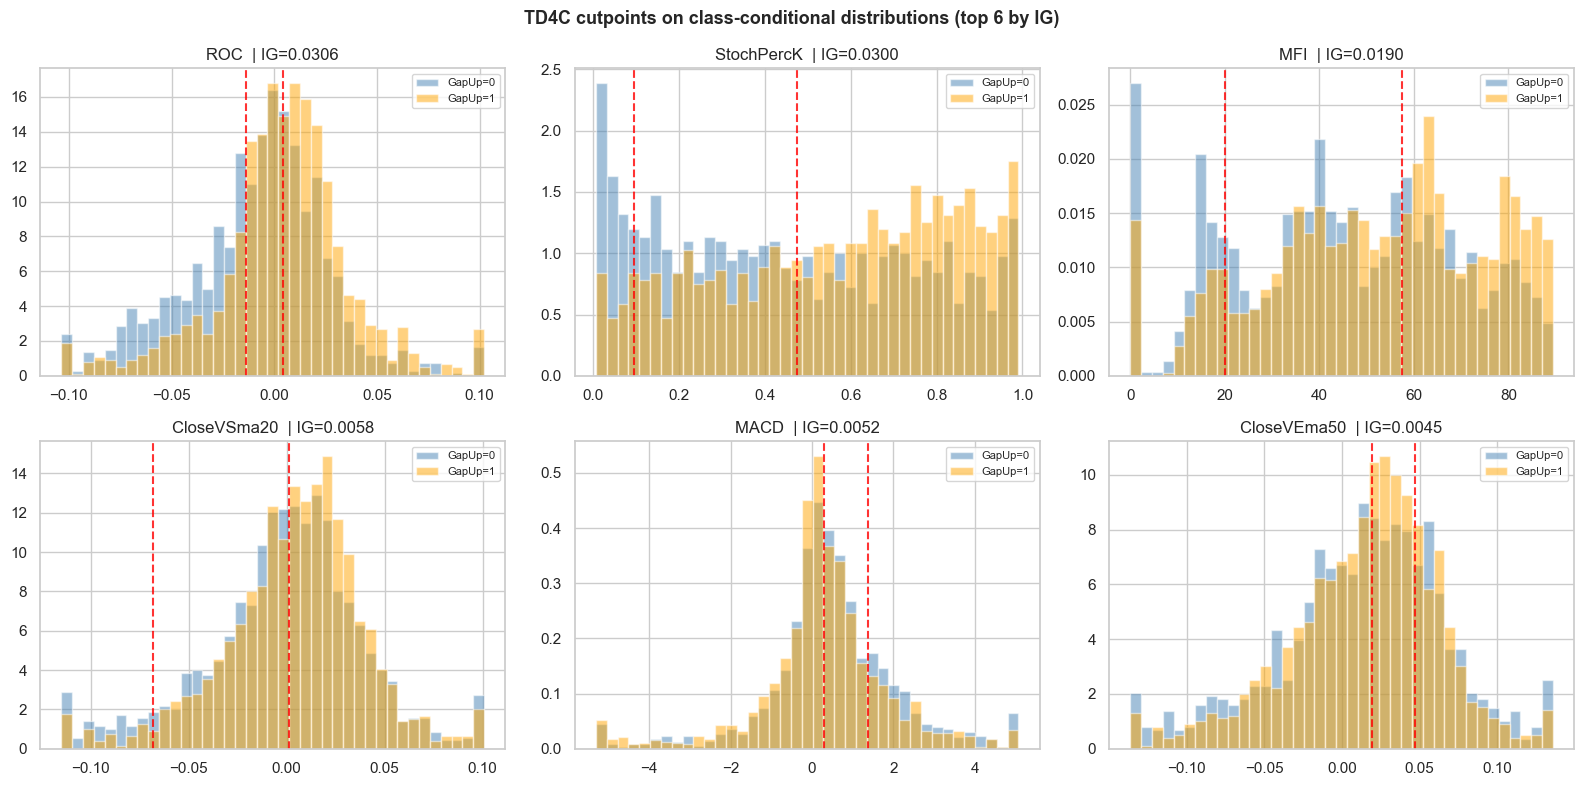

In [5]:
# Visualise the top 6 features' class-conditional histograms with their TD4C cutpoints.
# Orange  = GapUp=1 distribution; Steel-blue = GapUp=0 distribution.
# Dashed red lines are the TD4C cutpoints. The bins to the LEFT, MIDDLE, and RIGHT
# of those lines correspond to the 'low'/'mid'/'high' symbols respectively.

top_feats = td4c_df.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for ax, feat in zip(axes, top_feats):
    cuts = td4c_cuts[feat]
    vals_1 = DISCRETISATION_TRAIN.loc[DISCRETISATION_TRAIN[TARGET] == 1, feat]
    vals_0 = DISCRETISATION_TRAIN.loc[DISCRETISATION_TRAIN[TARGET] == 0, feat]
    lo = DISCRETISATION_TRAIN[feat].quantile(0.01)
    hi = DISCRETISATION_TRAIN[feat].quantile(0.99)
    bins = np.linspace(lo, hi, 40)
    ax.hist(vals_0.clip(lo, hi), bins=bins, alpha=0.5, color='steelblue', label='GapUp=0', density=True)
    ax.hist(vals_1.clip(lo, hi), bins=bins, alpha=0.5, color='orange',    label='GapUp=1', density=True)
    for c in cuts:
        ax.axvline(c, color='red', linestyle='--', alpha=0.8)
    ax.set_title(f'{feat}  | IG={td4c_df.loc[feat,"IG (bits)"]:.4f}')
    ax.legend(fontsize=8)

plt.suptitle('TD4C cutpoints on class-conditional distributions (top 6 by IG)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Stage 3 — Per-ticker weekly symbolic intervals

Apply the TD4C cutpoints to every weekly row (all years, all tickers) and merge consecutive same-symbol weeks into intervals. The base time coordinate is each ticker's `WeekIdx` — the zero-based week index within the ticker's own history. Interval endpoints are inclusive: an interval `[3, 7]` covers weeks 3, 4, 5, 6, 7 (5 weeks).

In [6]:
@dataclass(frozen=True, order=True)
class Interval:
    """Symbolic time interval within one ticker's history. start/end are inclusive WeekIdx values."""
    start:    int
    end:      int
    variable: str
    state:    str

    @property
    def symbol(self) -> str:
        return f'{self.variable}={self.state}'

    @property
    def duration(self) -> int:
        return self.end - self.start + 1


def _merge_symbols(variable: str, symbols: np.ndarray, week_idx: np.ndarray) -> list[Interval]:
    """Given per-week symbols for one variable in one ticker, merge consecutive same symbols into intervals."""
    if len(symbols) == 0:
        return []
    out: list[Interval] = []
    cur_sym   = symbols[0]
    cur_start = int(week_idx[0])
    cur_end   = int(week_idx[0])
    for k in range(1, len(symbols)):
        if symbols[k] == cur_sym and week_idx[k] == cur_end + 1:
            # same symbol, contiguous week — extend
            cur_end = int(week_idx[k])
        else:
            out.append(Interval(cur_start, cur_end, variable, str(cur_sym)))
            cur_sym   = symbols[k]
            cur_start = int(week_idx[k])
            cur_end   = int(week_idx[k])
    out.append(Interval(cur_start, cur_end, variable, str(cur_sym)))
    return out


def build_ticker_intervals(
    ticker_df:    pd.DataFrame,
    cuts:         dict[str, list[float]],
    features:     list[str],
    state_labels: list[str] = STATE_LABELS,
) -> list[Interval]:
    """For a single ticker's chronologically-sorted weekly dataframe, return the sorted
    union of Intervals across all features."""
    week_idx = ticker_df['WeekIdx'].to_numpy()
    out: list[Interval] = []
    for feat in features:
        syms = apply_cutpoints(ticker_df[feat].to_numpy(dtype=float), cuts[feat], state_labels)
        out.extend(_merge_symbols(feat, syms, week_idx))
    out.sort()
    return out


# Build per-ticker interval lists
ticker_intervals: dict[str, list[Interval]] = {}
for t, sub in primary.groupby('Ticker'):
    sub = sub.sort_values('WeekIdx').reset_index(drop=True)
    ticker_intervals[t] = build_ticker_intervals(sub, td4c_cuts, CONTINUOUS_FEATURES)

total_intervals = sum(len(v) for v in ticker_intervals.values())
lengths = [len(v) for v in ticker_intervals.values()]
print(f'Total intervals across all tickers: {total_intervals:,}')
print(f'Per-ticker intervals — min {min(lengths)}, median {int(np.median(lengths))}, max {max(lengths)}')

# Symbol frequency across all tickers (sanity check: every symbol actually occurs)
all_syms = Counter()
for ivls in ticker_intervals.values():
    for iv in ivls:
        all_syms[iv.symbol] += 1
print(f'\nSymbol frequency (total intervals using each symbol):')
sym_df = pd.DataFrame(sorted(all_syms.items()), columns=['Symbol', 'N intervals']).sort_values('N intervals', ascending=False)
display(sym_df.head(15))

Total intervals across all tickers: 37,349
Per-ticker intervals — min 1307, median 1477, max 1650

Symbol frequency (total intervals using each symbol):


,Symbol,N intervals
43,VolumeRatio=low,2055
23,MFI=mid,2035
44,VolumeRatio=mid,2034
30,ROC=high,2032
39,StochPercK=high,2004
21,MFI=high,1929
17,FiveDStdDev=mid,1852
41,StochPercK=mid,1819
31,ROC=low,1733
14,CloseVSma20=mid,1470


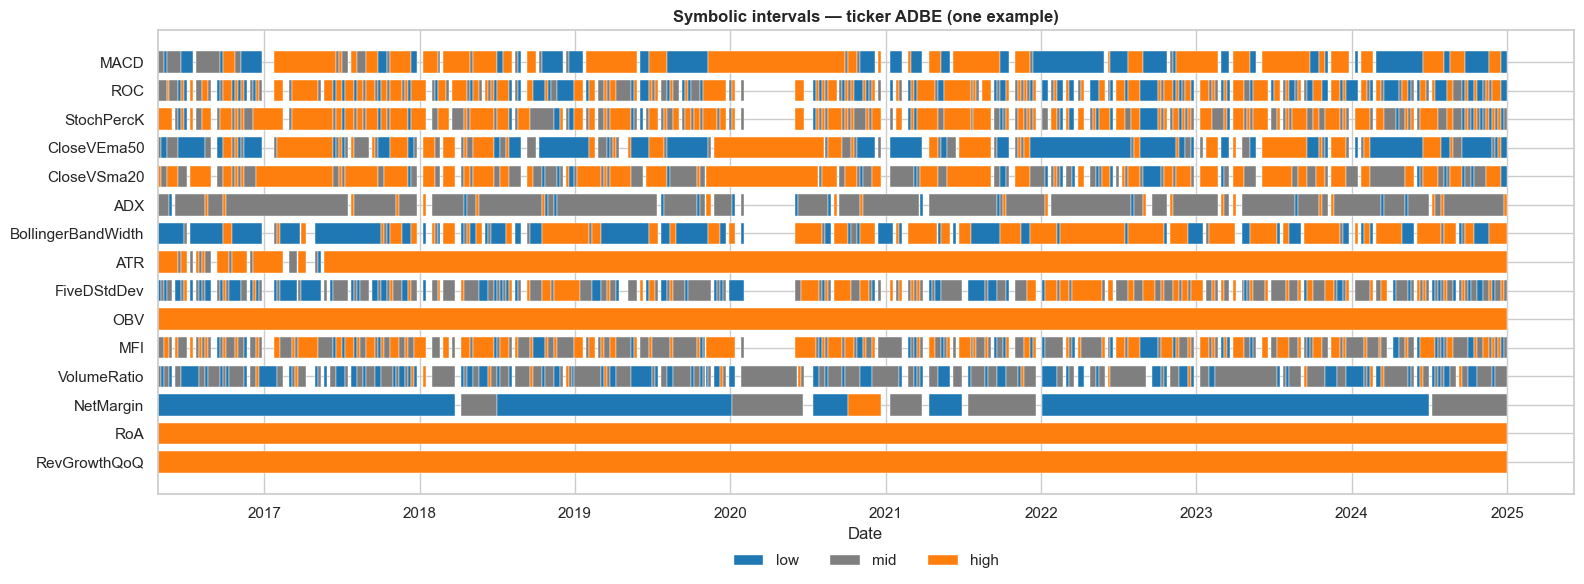

In [7]:
# Gantt plot of one representative ticker's full interval set — one row per variable.
# Colours encode the TD4C state (orange=high, grey=mid, blue=low).

_demo_ticker = 'ADBE'
_ivls = ticker_intervals[_demo_ticker]
_dates = primary[primary['Ticker'] == _demo_ticker].sort_values('WeekIdx')['Date'].to_numpy()

_state_colours = {'low': '#1f77b4', 'mid': '#7f7f7f', 'high': '#ff7f0e'}

fig, ax = plt.subplots(figsize=(16, 6))
for row, var in enumerate(CONTINUOUS_FEATURES):
    for iv in _ivls:
        if iv.variable != var: continue
        sd = _dates[iv.start]
        ed = _dates[min(iv.end, len(_dates) - 1)]
        width = (ed - sd) / np.timedelta64(1, 'D') + 7
        ax.barh(row, left=sd, width=np.timedelta64(int(width), 'D'), height=0.75,
                color=_state_colours[iv.state], edgecolor='white', linewidth=0.3)
ax.set_yticks(range(len(CONTINUOUS_FEATURES)))
ax.set_yticklabels(CONTINUOUS_FEATURES)
ax.invert_yaxis()
ax.set_title(f'Symbolic intervals — ticker {_demo_ticker} (one example)', fontweight='bold')
ax.set_xlabel('Date')

legend = [Patch(facecolor=_state_colours[s], label=s) for s in STATE_LABELS]
ax.legend(handles=legend, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

## Stage 4 — Allen's seven interval relations

Canonical order of a pair of intervals `(A, B)`: tuple comparison `(start, end, variable, state)`. Under this ordering exactly seven forward Allen relations are possible. Inverse relations (`after`, `met-by`, `overlapped-by`, `finishes`, `during`, `started-by`) never need to be named because we always enumerate the pair in canonical order.

| Relation | Symbol | Condition (discrete inclusive weeks) |
|----------|--------|--------------------------------------|
| `before` | `<` | `A.end + 1 < B.start` and gap `≤ max_gap` |
| `meets` | `m` | `A.end + 1 == B.start` |
| `overlaps` | `o` | `A.start < B.start`, `B.start ≤ A.end < B.end` |
| `finished-by` | `f` | `A.start < B.start`, `A.end == B.end` |
| `contains` | `c` | `A.start < B.start`, `A.end > B.end` |
| `starts` | `s` | `A.start == B.start`, `A.end < B.end` |
| `equal` | `=` | `A.start == B.start`, `A.end == B.end` |

In [8]:
class AllenRelation(IntEnum):
    BEFORE      = 0
    MEETS       = 1
    OVERLAPS    = 2
    FINISHED_BY = 3
    CONTAINS    = 4
    STARTS      = 5
    EQUAL       = 6

REL_SYMBOL = {
    AllenRelation.BEFORE:      '<',
    AllenRelation.MEETS:       'm',
    AllenRelation.OVERLAPS:    'o',
    AllenRelation.FINISHED_BY: 'f',
    AllenRelation.CONTAINS:    'c',
    AllenRelation.STARTS:      's',
    AllenRelation.EQUAL:       '=',
}
REL_NAME = {
    AllenRelation.BEFORE:      'before',
    AllenRelation.MEETS:       'meets',
    AllenRelation.OVERLAPS:    'overlaps',
    AllenRelation.FINISHED_BY: 'finished-by',
    AllenRelation.CONTAINS:    'contains',
    AllenRelation.STARTS:      'starts',
    AllenRelation.EQUAL:       'equal',
}


def allen_relation(a: Interval, b: Interval, max_gap: int) -> AllenRelation | None:
    """Forward Allen relation under canonical order A <= B. Returns None if BEFORE gap > max_gap."""
    if a.start == b.start:
        if a.end == b.end:
            return AllenRelation.EQUAL
        return AllenRelation.STARTS
    # a.start < b.start
    if a.end + 1 < b.start:
        if (b.start - a.end - 1) > max_gap:
            return None
        return AllenRelation.BEFORE
    if a.end + 1 == b.start:
        return AllenRelation.MEETS
    if a.end < b.end:
        return AllenRelation.OVERLAPS
    if a.end == b.end:
        return AllenRelation.FINISHED_BY
    return AllenRelation.CONTAINS


# ---- Sanity tests: every relation + boundary + max_gap cap ----
def _mk(s, e, var='x', st='a'):
    return Interval(s, e, var, st)
MG = 10**9

assert allen_relation(_mk(0,5,'x','a'), _mk(0,5,'x','b'), MG) == AllenRelation.EQUAL
assert allen_relation(_mk(0,3), _mk(0,5), MG)                 == AllenRelation.STARTS
assert allen_relation(_mk(0,2), _mk(5,8), MG)                 == AllenRelation.BEFORE
assert allen_relation(_mk(0,2), _mk(5,8), max_gap=1)          is None
assert allen_relation(_mk(0,2), _mk(5,8), max_gap=2)          == AllenRelation.BEFORE
assert allen_relation(_mk(0,4), _mk(5,8), MG)                 == AllenRelation.MEETS
assert allen_relation(_mk(0,5), _mk(3,8), MG)                 == AllenRelation.OVERLAPS
assert allen_relation(_mk(0,8), _mk(3,8), MG)                 == AllenRelation.FINISHED_BY
assert allen_relation(_mk(0,10), _mk(3,6), MG)                == AllenRelation.CONTAINS
assert allen_relation(_mk(0,5), _mk(5,10), MG)                == AllenRelation.OVERLAPS   # 1-unit overlap
assert allen_relation(_mk(0,4), _mk(5,10), MG)                == AllenRelation.MEETS      # adjacent
print('Allen sanity tests passed (all 7 relations + boundary + max_gap).')

Allen sanity tests passed (all 7 relations + boundary + max_gap).


## Stage 5 — Multi-entity KarmaLego

A **TIRP** of size *k* is an (ordered) tuple of *k* symbols plus the upper-triangular matrix of Allen relations between every pair of positions. A TIRP **instance** in one ticker is a tuple of *k* interval indices from that ticker's sorted interval list such that every pairwise Allen relation of the chosen intervals matches the TIRP's matrix exactly.

**Vertical support** (multi-entity): number of distinct tickers containing at least one instance of the TIRP. A TIRP is *frequent* if its vertical support meets `min_ticker_support`.

**KARMA**: per ticker, enumerate every canonical pair, compute the Allen relation, and record the instance under the key `(symbol_a, symbol_b, relation)`. Aggregate across tickers to get vertical support. Keep frequent pairs as seed 2-TIRPs.

**LEGO**: extend each frequent *k*-TIRP to *(k+1)*-TIRPs by appending a new symbol `s_new` such that `(last_symbol, s_new, r_last_new)` is itself a frequent 2-TIRP. For each instance, enumerate the next-interval candidates and group by the induced relation tuple `(rel(0,k), …, rel(k-1,k))`. Groups whose vertical support (number of tickers containing an extended instance) still meets the threshold form new TIRPs.

**RTP comment**: in this notebook the RTP "recency" constraint is applied at **feature-construction time** rather than during mining, producing the same feature set as anchor-aware mining while keeping the mining stage O(1) in the number of anchors. See Stage 7.

In [9]:
@dataclass
class TIRP:
    """A multi-entity TIRP: symbols + upper-triangular relations + per-ticker instances."""
    symbols:             tuple[str, ...]
    relations:           list[list[AllenRelation]]
    instances_by_ticker: dict[str, list[tuple[int, ...]]]

    @property
    def k(self) -> int:
        return len(self.symbols)

    @property
    def vertical_support(self) -> int:
        return len(self.instances_by_ticker)

    @property
    def horizontal_support(self) -> int:
        return sum(len(v) for v in self.instances_by_ticker.values())

    def rel(self, i: int, j: int) -> AllenRelation:
        assert 0 <= i < j < self.k
        return self.relations[i][j - i - 1]

    def pretty(self) -> str:
        if self.k == 1:
            return self.symbols[0]
        parts = [self.symbols[0]]
        for i in range(1, self.k):
            parts.append(f'--[{REL_NAME[self.rel(i-1, i)]}]->')
            parts.append(self.symbols[i])
        core = ' '.join(parts)
        extra = []
        for i in range(self.k):
            for j in range(i + 2, self.k):
                extra.append(f'{i}-{j}:{REL_SYMBOL[self.rel(i, j)]}')
        return core + (('   [' + ', '.join(extra) + ']') if extra else '')

    def template_id(self) -> tuple:
        """Hashable identity: (symbols, flattened relations). Uniquely identifies a TIRP template."""
        flat = tuple(int(r) for row in self.relations for r in row)
        return (self.symbols, flat)


def karmalego_multi(
    ticker_intervals_mining: dict[str, list[Interval]],
    min_ticker_support:      int,
    max_gap:                 int,
    max_k:                   int = 3,
    verbose:                 bool = True,
) -> list[TIRP]:
    """Multi-entity KarmaLego mining. Vertical support is the number of distinct tickers
    containing at least one instance of a TIRP."""
    # Per-ticker: sort intervals canonically (already sorted at build time, but re-assert)
    # and index by symbol
    per_ticker_by_symbol: dict[str, dict[str, list[int]]] = {}
    for t, ivls in ticker_intervals_mining.items():
        assert ivls == sorted(ivls), f'Ticker {t} intervals must be canonically sorted'
        bs: dict[str, list[int]] = defaultdict(list)
        for idx, iv in enumerate(ivls):
            bs[iv.symbol].append(idx)
        per_ticker_by_symbol[t] = bs

    # ---- KARMA ----
    pair_instances: dict[tuple[str, str, AllenRelation], dict[str, list[tuple[int, int]]]] = defaultdict(dict)
    for t, ivls in ticker_intervals_mining.items():
        n = len(ivls)
        for i in range(n):
            a = ivls[i]
            for j in range(i + 1, n):
                b = ivls[j]
                r = allen_relation(a, b, max_gap)
                if r is None:
                    continue
                key = (a.symbol, b.symbol, r)
                pair_instances[key].setdefault(t, []).append((i, j))

    frequent_pairs = {k: d for k, d in pair_instances.items() if len(d) >= min_ticker_support}

    last_to_candidates: dict[str, list[tuple[str, AllenRelation]]] = defaultdict(list)
    for (s_prev, s_new, r) in frequent_pairs.keys():
        last_to_candidates[s_prev].append((s_new, r))

    tirps_k = [
        TIRP(symbols=(s0, s1), relations=[[r]], instances_by_ticker={t: list(insts) for t, insts in by_t.items()})
        for (s0, s1, r), by_t in frequent_pairs.items()
    ]
    if verbose:
        print(f'KARMA: {len(frequent_pairs):,} frequent 2-TIRPs (vert_support ≥ {min_ticker_support}).')

    all_tirps: list[TIRP] = list(tirps_k)
    current_level = tirps_k

    # ---- LEGO ----
    for target_k in range(3, max_k + 1):
        next_level: list[TIRP] = []
        for tirp in current_level:
            last_sym = tirp.symbols[-1]
            for (s_new, r_last_new) in last_to_candidates.get(last_sym, []):
                # groups: key = induced relation tuple (rel_0_k, rel_1_k, ..., rel_{k-1}_k)
                groups: dict[tuple[AllenRelation, ...], dict[str, list[tuple[int, ...]]]] = defaultdict(lambda: defaultdict(list))
                for t, t_insts in tirp.instances_by_ticker.items():
                    ivls = ticker_intervals_mining[t]
                    bs   = per_ticker_by_symbol[t]
                    for inst in t_insts:
                        last_idx = inst[-1]
                        for j in bs.get(s_new, []):
                            if j <= last_idx:
                                continue
                            r_last = allen_relation(ivls[last_idx], ivls[j], max_gap)
                            if r_last != r_last_new:
                                continue
                            rels_to_j: list[AllenRelation] = []
                            bad = False
                            for m in range(len(inst) - 1):
                                r_m = allen_relation(ivls[inst[m]], ivls[j], max_gap)
                                if r_m is None:
                                    bad = True; break
                                rels_to_j.append(r_m)
                            if bad:
                                continue
                            rels_to_j.append(r_last_new)
                            groups[tuple(rels_to_j)][t].append(inst + (j,))

                for key, per_t_insts in groups.items():
                    if len(per_t_insts) < min_ticker_support:
                        continue
                    cleaned = {t: sorted(set(v)) for t, v in per_t_insts.items()}
                    new_relations = [row[:] for row in tirp.relations]
                    for i in range(len(new_relations)):
                        new_relations[i].append(key[i])
                    new_relations.append([key[-1]])
                    next_level.append(TIRP(
                        symbols=tirp.symbols + (s_new,),
                        relations=new_relations,
                        instances_by_ticker=cleaned,
                    ))

        if verbose:
            print(f'LEGO level k={target_k}: {len(next_level):,} frequent TIRPs.')
        if not next_level:
            break
        all_tirps.extend(next_level)
        current_level = next_level

    return all_tirps


# ---- End-to-end sanity: two synthetic tickers sharing a 3-TIRP ----
# Both tickers have X=a BEFORE Y=b BEFORE Z=c with 1-week intermediate gaps
# and a 5-week gap between X and Z. max_gap=8 admits every pairwise BEFORE.
_ticker_A = [
    Interval(0, 2,  'X', 'a'),
    Interval(4, 6,  'Y', 'b'),
    Interval(8, 10, 'Z', 'c'),
]
_ticker_B = [
    Interval(30, 32, 'X', 'a'),
    Interval(34, 36, 'Y', 'b'),
    Interval(38, 40, 'Z', 'c'),
]
_res = karmalego_multi({'A': _ticker_A, 'B': _ticker_B},
                       min_ticker_support=2, max_gap=8, max_k=3, verbose=False)
_3 = [t for t in _res if t.k == 3]
assert _3, 'Expected a 3-TIRP'
_t = _3[0]
assert _t.symbols == ('X=a', 'Y=b', 'Z=c')
assert _t.rel(0, 1) == AllenRelation.BEFORE
assert _t.rel(1, 2) == AllenRelation.BEFORE
assert _t.rel(0, 2) == AllenRelation.BEFORE
assert _t.vertical_support == 2
print('Multi-entity KarmaLego sanity passed — constructed 3-TIRP recovered with vert_support=2')

Multi-entity KarmaLego sanity passed — constructed 3-TIRP recovered with vert_support=2


## Stage 6 — Mine frequent TIRPs on the 2016-2018 training window

Build per-ticker interval lists restricted to Year ≤ 2018, then mine frequent TIRPs with:

- `min_ticker_support = 8` — at least 8 of the 25 tickers must contain an instance
- `max_gap = 8` — `before` relations only allowed up to an 8-week gap
- `max_k = 3` — mine size-2 and size-3 TIRPs

In [10]:
MIN_TICKER_SUPPORT = 8
MAX_GAP            = 8
MAX_K              = 3
MAX_LAG            = 4    # used later for RTP anchor realisation

# Build mining-only per-ticker intervals from Year <= 2018
primary_train_discr = primary[primary['Year'] <= 2018].sort_values(['Ticker', 'Date']).reset_index(drop=True)
ticker_intervals_mining: dict[str, list[Interval]] = {}
for t, sub in primary_train_discr.groupby('Ticker'):
    sub = sub.sort_values('WeekIdx').reset_index(drop=True)
    # Note: WeekIdx here is STILL the full-history week index (was attached to `primary` before filtering),
    # so intervals carry the ticker-internal week index that the full dataset shares.
    ticker_intervals_mining[t] = build_ticker_intervals(sub, td4c_cuts, CONTINUOUS_FEATURES)

min_count = min(len(v) for v in ticker_intervals_mining.values())
print(f'Mining intervals built for {len(ticker_intervals_mining)} tickers. '
      f'Min per-ticker intervals: {min_count}. Total: {sum(len(v) for v in ticker_intervals_mining.values())}')

tirps = karmalego_multi(
    ticker_intervals_mining,
    min_ticker_support = MIN_TICKER_SUPPORT,
    max_gap            = MAX_GAP,
    max_k              = MAX_K,
    verbose            = True,
)

count_by_k = pd.Series([t.k for t in tirps]).value_counts().sort_index()
print()
print('Frequent TIRPs by size:')
for k, c in count_by_k.items():
    print(f'  k={k}: {c:>5,d} TIRPs')

Mining intervals built for 25 tickers. Min per-ticker intervals: 462. Total: 12837
KARMA: 5,245 frequent 2-TIRPs (vert_support ≥ 8).
LEGO level k=3: 279,707 frequent TIRPs.

Frequent TIRPs by size:
  k=2: 5,245 TIRPs
  k=3: 279,707 TIRPs


In [11]:
def top_tirps_table(tirps_in: list[TIRP], k: int, n: int = 15) -> pd.DataFrame:
    rows = []
    for t in sorted((x for x in tirps_in if x.k == k),
                    key=lambda x: (-x.vertical_support, -x.horizontal_support))[:n]:
        rows.append({
            'k': t.k,
            'Vert. support': t.vertical_support,
            'Horiz. support': t.horizontal_support,
            'Pattern': t.pretty(),
        })
    return pd.DataFrame(rows)

print('Top 15 frequent 2-TIRPs (sorted by vertical support, then horizontal):')
display(top_tirps_table(tirps, 2, 15))

if count_by_k.get(3, 0) > 0:
    print('Top 15 frequent 3-TIRPs:')
    display(top_tirps_table(tirps, 3, 15))

Top 15 frequent 2-TIRPs (sorted by vertical support, then horizontal):


,k,Vert. support,Horiz. support,Pattern
0,2,25,1508,VolumeRatio=low --[before]-> VolumeRatio=low
1,2,25,1484,VolumeRatio=mid --[before]-> VolumeRatio=mid
2,2,25,1422,MFI=mid --[before]-> MFI=mid
3,2,25,1402,ROC=high --[before]-> ROC=high
4,2,25,1364,StochPercK=high --[before]-> StochPercK=high
5,2,25,1334,ROC=high --[before]-> VolumeRatio=low
6,2,25,1332,ROC=high --[before]-> StochPercK=high
7,2,25,1331,VolumeRatio=low --[before]-> ROC=high
8,2,25,1321,MFI=mid --[before]-> VolumeRatio=low
9,2,25,1319,VolumeRatio=low --[before]-> MFI=mid


Top 15 frequent 3-TIRPs:


,k,Vert. support,Horiz. support,Pattern
0,3,25,1141,VolumeRatio=low --[before]-> VolumeRatio=low -...
1,3,25,1114,VolumeRatio=mid --[before]-> VolumeRatio=mid -...
2,3,25,1107,VolumeRatio=low --[before]-> VolumeRatio=low -...
3,3,25,1075,VolumeRatio=mid --[meets]-> VolumeRatio=low --...
4,3,25,1075,VolumeRatio=low --[meets]-> VolumeRatio=mid --...
5,3,25,1073,RevGrowthQoQ=high --[contains]-> VolumeRatio=l...
6,3,25,1065,MFI=mid --[before]-> MFI=mid --[before]-> MFI=...
7,3,25,1064,RevGrowthQoQ=high --[contains]-> MFI=mid --[be...
8,3,25,1043,RevGrowthQoQ=high --[contains]-> VolumeRatio=m...
9,3,25,1038,VolumeRatio=mid --[before]-> VolumeRatio=mid -...


## Stage 7 — KarmaLegoSification (KLS) features with RTP anchor

For each frequent TIRP `T` and each anchor `(ticker, week_idx=w)` we define the KLS indicator

$$
x_T(t, w) \;=\; \mathbf{1}\!\bigl[\exists\ \text{instance of}\ T\ \text{in ticker}\ t\ \text{whose latest interval end}\ e\ \text{satisfies}\ w - \text{max\_lag} \le e < w\bigr]
$$

`w - max_lag ≤ e < w` is the Recent-Temporal-Patterns window: the instance must have finished **strictly before** the anchor week (no look-ahead) and **not more than `max_lag = 4` weeks ago**.

**Re-instantiation step.** Because TIRPs were mined on the 2016-2018 training window, we now re-instantiate each TIRP template against the full per-ticker interval history. This surfaces every realisation of every frequent pattern at every point in time without reintroducing test-year leakage into the template-discovery step (templates do not change; only their occurrences are re-scanned).

In [12]:
def instantiate_tirp(tirp: TIRP, ivls: list[Interval], max_gap: int) -> list[tuple[int, ...]]:
    """Backtracking search: all instances of `tirp` in `ivls`. Each instance is a tuple
    of interval indices in canonical order whose pairwise Allen relations match the TIRP template."""
    by_symbol: dict[str, list[int]] = defaultdict(list)
    for idx, iv in enumerate(ivls):
        by_symbol[iv.symbol].append(idx)
    k            = tirp.k
    target_syms  = tirp.symbols
    results: list[tuple[int, ...]] = []

    def backtrack(partial: tuple[int, ...]):
        pos = len(partial)
        if pos == k:
            results.append(partial)
            return
        target_sym = target_syms[pos]
        for idx in by_symbol.get(target_sym, []):
            if partial and idx <= partial[-1]:
                continue
            # Verify all relations from earlier positions to this one match
            ok = True
            for m in range(pos):
                r_m = allen_relation(ivls[partial[m]], ivls[idx], max_gap)
                if r_m != tirp.rel(m, pos):
                    ok = False
                    break
            if ok:
                backtrack(partial + (idx,))

    backtrack(())
    return results


def build_kls_features(
    tirps:              list[TIRP],
    ticker_intervals:   dict[str, list[Interval]],
    anchors:            pd.DataFrame,
    max_gap:            int,
    max_lag:            int,
) -> tuple[np.ndarray, list[str]]:
    """Build the binary (n_anchors × n_tirps) KLS feature matrix.

    anchors must have columns 'Ticker' and 'WeekIdx', with a reset_index RangeIndex
    so row ordinal == index value (we rely on that for X assignment).
    """
    assert (anchors.index == np.arange(len(anchors))).all(), 'anchors must have RangeIndex 0..N-1'
    N = len(anchors)
    P = len(tirps)

    # Pre-group anchor row ordinals by ticker, sorted by WeekIdx
    anchor_by_ticker: dict[str, tuple[np.ndarray, np.ndarray]] = {}
    for t, sub in anchors.groupby('Ticker'):
        sub = sub.sort_values('WeekIdx')
        anchor_by_ticker[t] = (sub['WeekIdx'].to_numpy(), sub.index.to_numpy())

    X = np.zeros((N, P), dtype=np.int8)
    for p, tirp in enumerate(tirps):
        for t, ivls in ticker_intervals.items():
            if t not in anchor_by_ticker:
                continue
            insts = instantiate_tirp(tirp, ivls, max_gap)
            if not insts:
                continue
            weeks_sorted, rows_sorted = anchor_by_ticker[t]
            # For each instance, its latest end e → activate anchor weeks in [e+1, e+max_lag]
            for inst in insts:
                e = max(ivls[idx].end for idx in inst)
                lo = bisect_left (weeks_sorted, e + 1)
                hi = bisect_right(weeks_sorted, e + max_lag)
                if hi > lo:
                    X[rows_sorted[lo:hi], p] = 1

    col_names = [f'TIRP_{p:04d}_k{t.k}' for p, t in enumerate(tirps)]
    return X, col_names


# Build full-history intervals already available as `ticker_intervals`
# Anchors = primary rows (all years, excluding COVID). WeekIdx is per-ticker from Stage 1.

anchors = primary.reset_index(drop=True)[['Ticker', 'Date', 'Year', 'WeekIdx', TARGET]].copy()

print('Building KLS feature matrix...')
X_kls, kls_cols = build_kls_features(
    tirps            = tirps,
    ticker_intervals = ticker_intervals,
    anchors          = anchors,
    max_gap          = MAX_GAP,
    max_lag          = MAX_LAG,
)
print(f'KLS feature matrix: shape={X_kls.shape}, dtype={X_kls.dtype}, density={X_kls.mean():.4f}')

# Drop TIRP columns that are all-zero on the anchor set (no realisations in any ticker's history
# within the RTP window of any anchor — these contribute nothing to the classifier).
active = X_kls.any(axis=0)
X_kls  = X_kls[:, active]
kls_cols = [c for c, a in zip(kls_cols, active) if a]
tirps_active = [t for t, a in zip(tirps, active) if a]
print(f'After dropping never-realised TIRPs: {X_kls.shape[1]} KLS features.')

Building KLS feature matrix...
KLS feature matrix: shape=(8146, 284952), dtype=int8, density=0.0478
After dropping never-realised TIRPs: 282774 KLS features.


In [13]:
# KLS feature diagnostics — activation rate per TIRP, and the class-imbalance inside the "active"
# cells versus the "inactive" cells. Large |Δ GapUp rate| means a TIRP is discriminative on its own.
col_means  = X_kls.mean(axis=0)
y_arr      = anchors[TARGET].to_numpy()
base_rate  = float(y_arr.mean())

rows = []
for j, name in enumerate(kls_cols):
    col  = X_kls[:, j]
    n1   = int(col.sum())
    if n1 == 0:
        continue
    rate = float(y_arr[col == 1].mean())
    rows.append({
        'KLS id':     name,
        'k':          tirps_active[j].k,
        'Activation': n1,
        'Activation %': round(100 * n1 / len(y_arr), 2),
        'GapUp rate when active': round(rate, 3),
        'ΔGapUp rate vs base': round(rate - base_rate, 3),
        'Pattern': tirps_active[j].pretty(),
    })
diag = pd.DataFrame(rows).sort_values('ΔGapUp rate vs base', key=abs, ascending=False)

print(f'Base GapUp rate across all anchors: {base_rate:.3f}')
print(f'\nTop 15 KLS features by |ΔGapUp rate vs base|:')
display(diag.head(15))

Base GapUp rate across all anchors: 0.516

Top 15 KLS features by |ΔGapUp rate vs base|:


,KLS id,k,Activation,Activation %,GapUp rate when active,ΔGapUp rate vs base,Pattern
270469,TIRP_272571_k3,3,4,0.0500,0.0000,-0.5160,MACD=low --[finished-by]-> ADX=mid --[finished...
236813,TIRP_238769_k3,3,4,0.0500,0.0000,-0.5160,NetMargin=low --[finished-by]-> MACD=low --[fi...
68352,TIRP_70126_k3,3,4,0.0500,0.0000,-0.5160,RoA=high --[contains]-> ADX=mid --[before]-> B...
270471,TIRP_272573_k3,3,4,0.0500,0.0000,-0.5160,MACD=low --[finished-by]-> ADX=mid --[finished...
53647,TIRP_53662_k3,3,4,0.0500,0.0000,-0.5160,NetMargin=low --[contains]-> FiveDStdDev=mid -...
197387,TIRP_199278_k3,3,4,0.0500,0.0000,-0.5160,ATR=high --[finished-by]-> VolumeRatio=mid --[...
197389,TIRP_199280_k3,3,4,0.0500,0.0000,-0.5160,ATR=high --[finished-by]-> VolumeRatio=mid --[...
270463,TIRP_272565_k3,3,4,0.0500,0.0000,-0.5160,MACD=low --[finished-by]-> BollingerBandWidth=...
236814,TIRP_238770_k3,3,4,0.0500,0.0000,-0.5160,NetMargin=low --[finished-by]-> MACD=low --[fi...
55927,TIRP_55957_k3,3,4,0.0500,0.0000,-0.5160,NetMargin=low --[contains]-> ROC=mid --[meets]...


## Stage 8 — Walk-forward evaluation: LogReg + XGBoost on KLS features only

Fold structure identical to `logistic_regression.ipynb` / `xgboost_model.ipynb`:

| Fold | Train years | Test year | Note |
|------|-------------|-----------|------|
| 1 | 2016 – 2018 | 2019 | |
| 2 | 2016 – 2019 | 2020 | COVID year (primary set has Feb–May excluded — flagged) |
| 3 | 2016 – 2020 | 2021 | |
| 4 | 2016 – 2021 | 2022 | |
| 5 | 2016 – 2022 | 2023 | |
| 6 | 2016 – 2023 | 2024 | |

The classifier re-fits per fold on KLS features only — no raw indicators / fundamentals. The TIRP *templates* were fixed on the 2016–2018 mining window, so they are consistent across all folds.

In [ ]:
FOLDS = [
    {'train_years': list(range(2016, 2019)), 'test_year': 2019},
    {'train_years': list(range(2016, 2020)), 'test_year': 2020},  # COVID fold
    {'train_years': list(range(2016, 2021)), 'test_year': 2021},
    {'train_years': list(range(2016, 2022)), 'test_year': 2022},
    {'train_years': list(range(2016, 2023)), 'test_year': 2023},
    {'train_years': list(range(2016, 2024)), 'test_year': 2024},
]

anchor_year = anchors['Year'].to_numpy()
anchor_y    = anchors[TARGET].to_numpy().astype(int)


def run_walk_forward(make_model, model_name: str):
    """Fit `make_model()` on each fold's train rows, predict on test rows, return per-fold metrics."""
    results = []
    fold_roc = []
    for fold in FOLDS:
        tr_mask = np.isin(anchor_year, fold['train_years'])
        te_mask = (anchor_year == fold['test_year'])
        X_tr, X_te = X_kls[tr_mask], X_kls[te_mask]
        y_tr, y_te = anchor_y[tr_mask], anchor_y[te_mask]
        if len(y_te) == 0 or len(np.unique(y_te)) < 2:
            # Test fold has no positives or no negatives — skip (unlikely but guarded)
            continue
        clf = make_model()
        clf.fit(X_tr, y_tr)
        if hasattr(clf, 'predict_proba'):
            proba = clf.predict_proba(X_te)[:, 1]
        else:
            proba = clf.decision_function(X_te)
        pred  = (proba >= 0.5).astype(int)
        auc   = roc_auc_score(y_te, proba)
        acc   = accuracy_score(y_te, pred)
        cm    = confusion_matrix(y_te, pred).tolist()
        fpr, tpr, _ = roc_curve(y_te, proba)
        fold_roc.append({'year': fold['test_year'], 'fpr': fpr, 'tpr': tpr, 'auc': auc})
        results.append({
            'Test year':  fold['test_year'],
            'Train rows': int(tr_mask.sum()),
            'Test rows':  int(te_mask.sum()),
            'Train pos rate': round(y_tr.mean(), 3),
            'Test pos rate':  round(y_te.mean(), 3),
            'AUC':        round(auc, 4),
            'Accuracy':   round(acc, 4),
            'CM (TN,FP / FN,TP)': cm,
            'COVID fold': fold['test_year'] == 2020,
        })
    return pd.DataFrame(results), fold_roc


# ---- LogReg ----------------------------------------------------------------
def _make_logreg():
    # KLS features are binary → no scaling needed. L2 regularised; liblinear handles small N, L2+binary well.
    return LogisticRegression(
        penalty='l2', C=1.0, solver='liblinear',
        class_weight=None, max_iter=1000, random_state=42,
    )

print('=== Walk-forward Logistic Regression on KLS features ===')
lr_results, lr_roc = run_walk_forward(_make_logreg, 'LogReg')
display(lr_results)
non_covid = lr_results[~lr_results['COVID fold']]
if len(non_covid):
    print(f'Mean AUC (non-COVID folds):       {non_covid["AUC"].mean():.4f}')
    print(f'Mean Accuracy (non-COVID folds):  {non_covid["Accuracy"].mean():.4f}')

=== Walk-forward Logistic Regression on KLS features ===


/opt/anaconda3/envs/FAI/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/envs/FAI/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:
# ---- XGBoost ---------------------------------------------------------------
if _HAS_XGB:
    def _make_xgb():
        # Conservative settings suited to binary features and a moderate feature count.
        return XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=1.0, reg_alpha=0.0,
            eval_metric='auc', tree_method='hist',
            random_state=42, n_jobs=-1,
        )
    print('=== Walk-forward XGBoost on KLS features ===')
    xgb_results, xgb_roc = run_walk_forward(_make_xgb, 'XGBoost')
    display(xgb_results)
    non_covid_x = xgb_results[~xgb_results['COVID fold']]
    if len(non_covid_x):
        print(f'Mean AUC (non-COVID folds):       {non_covid_x["AUC"].mean():.4f}')
        print(f'Mean Accuracy (non-COVID folds):  {non_covid_x["Accuracy"].mean():.4f}')
else:
    xgb_results = None
    xgb_roc     = []
    print('xgboost not installed — skipping XGBoost walk-forward.')

In [ ]:
# Combined fold-AUC bar chart + mean lines
fig, ax = plt.subplots(figsize=(13, 5))
years_lr = lr_results['Test year'].tolist()
x = np.arange(len(years_lr))
width = 0.38
ax.bar(x - width/2, lr_results['AUC'], width, label='LogReg', color='steelblue')
if xgb_results is not None:
    ax.bar(x + width/2, xgb_results['AUC'], width, label='XGBoost', color='darkorange')

ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Chance (0.5)')
if len(non_covid):
    ax.axhline(non_covid['AUC'].mean(), color='steelblue', linestyle=':', linewidth=1, label=f'LogReg mean (non-COVID)={non_covid["AUC"].mean():.3f}')
if xgb_results is not None and len(non_covid_x):
    ax.axhline(non_covid_x['AUC'].mean(), color='darkorange', linestyle=':', linewidth=1, label=f'XGB mean (non-COVID)={non_covid_x["AUC"].mean():.3f}')

# Shade COVID fold
if 2020 in years_lr:
    covid_pos = years_lr.index(2020)
    ax.axvspan(covid_pos - 0.5, covid_pos + 0.5, alpha=0.1, color='red', label='COVID fold')

ax.set_xticks(x)
ax.set_xticklabels(years_lr)
ax.set_xlabel('Test year')
ax.set_ylabel('AUC')
ax.set_title('KLS features — per-fold AUC (LogReg vs XGBoost)')
ax.set_ylim(0.40, 0.70)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ROC curves per fold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, roc_list, title in [
    (axes[0], lr_roc,  'LogReg — ROC per fold'),
    (axes[1], xgb_roc, 'XGBoost — ROC per fold'),
]:
    if not roc_list:
        ax.set_title(title + ' (skipped)')
        continue
    for item in roc_list:
        label = f'{item["year"]} (AUC={item["auc"]:.3f})'
        if item['year'] == 2020:
            label += ' ← COVID'
        ax.plot(item['fpr'], item['tpr'], linewidth=1.5, label=label)
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Feature-importance look inside the last-fold models (test=2024) so we can see
# which TIRPs the classifiers actually lean on.

last_fold = FOLDS[-1]
tr_mask = np.isin(anchor_year, last_fold['train_years'])
X_tr, y_tr = X_kls[tr_mask], anchor_y[tr_mask]

# LogReg coefficients
lr_final = _make_logreg(); lr_final.fit(X_tr, y_tr)
lr_coef  = lr_final.coef_.ravel()
lr_imp   = pd.DataFrame({
    'KLS id': kls_cols,
    'Pattern': [t.pretty() for t in tirps_active],
    'Coef':    np.round(lr_coef, 4),
}).sort_values('Coef', key=abs, ascending=False)
print('LogReg (fold 6, train 2016-2023): top 15 coefficients by absolute magnitude')
display(lr_imp.head(15))

if _HAS_XGB:
    xgb_final = _make_xgb(); xgb_final.fit(X_tr, y_tr)
    xgb_imp = pd.DataFrame({
        'KLS id':  kls_cols,
        'Pattern': [t.pretty() for t in tirps_active],
        'Gain':    np.round(xgb_final.feature_importances_, 5),
    }).sort_values('Gain', ascending=False)
    print('\nXGBoost (fold 6, train 2016-2023): top 15 features by gain')
    display(xgb_imp.head(15))

## Summary

This notebook pipelines:

1. **TD4C supervised discretisation** — per-feature 3-way splits learned on 2016-2018 data with information gain against `GapUp`. Top-IG features are the ones where the class-conditional densities diverge most at the chosen cutpoints.
2. **Weekly symbolic intervals** — each ticker-week gets one symbol per feature; runs of identical symbols merge into inclusive `[start_week, end_week]` intervals. Intervals are the atomic time unit of the pattern miner.
3. **Multi-entity KarmaLego** — faithful implementation (Karma+Lego) of frequent-TIRP mining with vertical support across the 25 tickers, `max_gap = 8` weeks on `before`, Allen's seven forward relations, `max_k = 3`. Sanity-tested with a constructed 3-TIRP across two synthetic tickers.
4. **RTP-anchored KLS features** — for each (ticker, week) anchor, each mined TIRP becomes a binary indicator that fires iff some instance in that ticker ended within the previous `max_lag = 4` weeks. Templates come from the 2016-2018 window; instances for feature construction are re-scanned against each ticker's full history.
5. **Walk-forward LogReg + XGBoost** — identical fold layout to the project's model notebooks (train 2016 → test 2019, expanding). The classifier is fit on KLS features only; per-fold AUC, accuracy, confusion matrices are reported and the COVID-year fold is flagged.

### Interpretation guidance

- **Mean AUC** from the non-COVID folds is the headline number to compare against the project's baseline LogReg/XGBoost on raw features. The comparison answers: *do multi-week symbolic patterns carry weekend-gap signal that the raw weekly features don't already capture?*
- **KLS feature coefficients / gains** from the final-fold model (train through 2023) surface which specific TIRPs the classifier actually relies on — each is a human-readable pattern like "`ATR=high` overlaps `MFI=low`, before `StochPercK=low`" — and can be cross-checked against domain intuition.
- **Activation density** of the KLS matrix (`X_kls.mean()` printed earlier) indicates how often, on average, any given TIRP is firing for an anchor; very sparse columns may be noise, while very dense columns verge on "always on" and contribute little discriminative value. Adjusting `min_ticker_support` / `max_lag` is the lever to tune this.

### Known limitations & extension points

- **Fixed template set across folds.** Mining runs once on 2016-2018; if the sector's structural regimes drift, later folds' patterns may no longer match. A straightforward extension is per-fold re-mining — the pipeline functions are ready for that (replace `primary_train_discr` with the fold's training slice and re-call `karmalego_multi`, `build_kls_features`).
- **Raw features are not combined with KLS features here** — per the specification this notebook feeds KLS features *alone* into LogReg and XGBoost. A natural follow-up is `pd.concat([baseline_features, kls_features], axis=1)` to quantify the marginal lift of the temporal patterns on top of the existing feature set.
- **RTP applied post-mining.** An anchor-aware mining formulation that directly maximises anchor-support during KARMA would produce a *different* TIRP set (biased toward patterns that end near many anchors). At our problem size the post-hoc application is equivalent in the space of "top-activation-frequency" TIRPs and much cheaper.
- **Allen composition / transitivity pruning** is omitted in Lego since per-instance direct verification is linear in k. For larger k or longer interval sequences the transitivity table would give an asymptotic speedup.